# Import

In [70]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import dbetto
import lh5

import pygeomhades
import pygeomtools
from pygeomtools import write_pygeom
import pyg4ometry as pg4
from pyg4ometry import gdml

%matplotlib inline

#logging.basicConfig(level=logging.INFO)
#logging.getLogger('numba').setLevel(logging.INFO)
#logging.getLogger('parse').setLevel(logging.INFO)

# functions


In [65]:
import reboost
from reboost import hpge
from reboost.hpge import surface, psd
from reboost.shape import group
from reboost.math import functions
from reboost.math.stats import gaussian_sample
from reboost.utils import get_remage_detector_uids




# Functions

In [ ]:
def find_matching_background_runs(db, detector, measure, campaign="c1"):
    configuration = db.hardware.configuration[detector][campaign]

    physics_runs = configuration[measure]
    background_runs = configuration["bkg"]

    matches = {}

    for run, data in sorted(physics_runs.items()):
        if not run.startswith("run"):
            continue

        card = data["daq_settings"]["flashcam"]["card_interface"]

        matching_bkg = [
            bkg_run
            for bkg_run, bkg_data in sorted(background_runs.items())
            if bkg_run.startswith("run")
            and bkg_data["daq_settings"]["flashcam"]["card_interface"] == card
        ]

        matches[run] = {
            "card_interface": card,
            "background_runs": matching_bkg,
        }

    return matches

In [ ]:
def histogram_from_lh5(file_names, bins):
    counts = np.zeros(len(bins) - 1, dtype=np.int64)

    for file_name in tqdm(file_names, desc="Lettura spettro"):
        energy = lh5.read(
            "hit/cuspEmax_ctc_cal",
            file_name,
        ).nda

        counts += np.histogram(energy, bins=bins)[0]

    return counts

In [ ]:
def find_matching_detector_runs(
    db,
    detector_1,
    detector_2,
    campaign=campaign,
    position_tolerance=1e-6,
    measure=measure,
):
    config_1 = db.hardware.configuration[detector_1][campaign]
    config_2 = db.hardware.configuration[detector_2][campaign]

    common_measures = sorted(
        (set(config_1) & set(config_2)) - {"bkg"}
    )

    # Se measure è specificata, considera soltanto quella misura.
    # Con measure=None considera tutte le misure comuni.
    if measure is not None:
        common_measures = [
            name for name in common_measures
            if name == measure
        ]

    if not common_measures:
        raise ValueError(
            f"Nessuna misura comune per il filtro measure={measure!r}."
        )

    pairs = {}
    metadata = {}

    for measurement in common_measures:
        pairs[measurement] = []

        runs_1 = get_run_names(config_1[measurement])
        runs_2 = get_run_names(config_2[measurement])

        print(f"\n{measurement}")
        print(f"{detector_1}: {runs_1}")
        print(f"{detector_2}: {runs_2}")

        for detector, runs in (
            (detector_1, runs_1),
            (detector_2, runs_2),
        ):
            for run in runs:
                key = (detector, measurement, run)

                metadata[key] = get_run_metadata(
                    db, detector, measurement, run, campaign
                )

        for run_1 in runs_1:
            key_1 = (detector_1, measurement, run_1)

            for run_2 in runs_2:
                key_2 = (detector_2, measurement, run_2)

                if same_run_setup(
                    metadata[key_1],
                    metadata[key_2],
                    position_tolerance,
                ):
                    pairs[measurement].append((key_1, key_2))

    return common_measures, pairs, metadata

In [ ]:
common_measures, pairs, metadata = find_matching_detector_runs(
    db,
    detector_1="V03421A",
    detector_2="V03422A",
    measure=measure,
)

In [ ]:
for measurement, matched_pairs in pairs.items():
    print(f"\n{measurement}: {len(matched_pairs)} coppie")
    for key_1, key_2 in matched_pairs:
        print(key_1[2], "↔", key_2[2])

In [ ]:
for detector in ("V03421A", "V03422A"):
    configuration = (
        db.hardware.configuration[detector][campaign][measure]
    )

    print(f"\n{detector} — {measure}")

    for run in get_run_names(configuration):
        meta = get_run_metadata(
            db, detector, measure, run, campaign
        )

        print(
            run,
            "| card:", get_card_interface(meta),
            "| posizione:", dict(meta["source_position"]),
            "| tempo:", meta["run_live_time_in_s"],
        )

In [ ]:

# ============================================================
# CONFIGURAZIONE
# ============================================================

version = "v1.2.1"
measure = "am_HS1_top_dlt"
campaign = "c1"

metadata_path = "/global/u2/r/ritaferi/HADES_DATA/hades-metadata"
db = dbetto.TextDB(metadata_path)


In [51]:
def get_run_metadata(db, detector, measurement, run, campaign):
    return (
        db.hardware.configuration[detector]
        [campaign][measurement][run]
    )





def get_card_interface(meta):
    return meta["daq_settings"]["flashcam"]["card_interface"]


def get_run_names(configuration):
    return sorted(
        key
        for key in configuration
        if key.startswith("run") and key[3:].isdigit()
    )

def same_run_setup(
    meta_1,
    meta_2,
    position_tolerance=5.0,
    phi_tolerance=5.0,
):
    if get_card_interface(meta_1) != get_card_interface(meta_2):
        return False

    pos_1 = meta_1["source_position"]
    pos_2 = meta_2["source_position"]

    for key in ("r_in_mm", "z_in_mm"):
        difference = abs(float(pos_1[key]) - float(pos_2[key]))

        if difference > position_tolerance:
            return False

    # Distanza angolare: 0° e 360° sono equivalenti.
    delta_phi = (
        float(pos_1["phi_in_deg"])
        - float(pos_2["phi_in_deg"])
        + 180
    ) % 360 - 180

    return abs(delta_phi) <= phi_tolerance

def find_matching_detector_runs(
    db,
    detector_1,
    detector_2,
    campaign=campaign,
    measure=measure,
    position_tolerance=5.0,
    phi_tolerance=5.0,
):
    config_1 = db.hardware.configuration[detector_1][campaign]
    config_2 = db.hardware.configuration[detector_2][campaign]

    common_measures = sorted(
        (set(config_1) & set(config_2)) - {"bkg"}
    )

    # measure=None: considera tutte le misure comuni.
    if measure is not None:
        common_measures = [
            name for name in common_measures
            if name == measure
        ]

    if not common_measures:
        raise ValueError(
            f"Nessuna misura comune per measure={measure!r}."
        )

    pairs = {}
    metadata = {}

    for measurement in common_measures:
        pairs[measurement] = []

        runs_1 = get_run_names(config_1[measurement])
        runs_2 = get_run_names(config_2[measurement])

        for detector, runs in (
            (detector_1, runs_1),
            (detector_2, runs_2),
        ):
            for run in runs:
                key = (detector, measurement, run)

                metadata[key] = get_run_metadata(
                    db,
                    detector,
                    measurement,
                    run,
                    campaign,
                )

        # Confronta tutte le coppie, anche con numeri diversi di run.
        for run_1 in runs_1:
            key_1 = (detector_1, measurement, run_1)

            for run_2 in runs_2:
                key_2 = (detector_2, measurement, run_2)

                if same_run_setup(
                    metadata[key_1],
                    metadata[key_2],
                    position_tolerance=position_tolerance,
                    phi_tolerance=phi_tolerance,
                ):
                    pairs[measurement].append((key_1, key_2))

    return common_measures, pairs, metadata

# ============================================================
# FILE LH5 E ISTOGRAMMA DI UN SINGOLO RUN
# ============================================================

def get_run_files(detector, measurement, run, version, campaign):
    run_number = int(run[3:])

    pattern = (
        "/global/cfs/cdirs/m2676/data/teststands/hades/"
        f"prodenv/ref/{version}/generated/tier/hit/"
        f"{detector}/{campaign}/{measurement}/"
        f"char_data-{detector}-{measurement}"
        f"-r{run_number:03d}-*-tier_hit.lh5"
    )

    files = sorted(glob.glob(pattern))

    if not files:
        raise FileNotFoundError(
            f"Nessun file per {detector}, {measurement}, {run}\n"
            f"Pattern: {pattern}"
        )

    return files

from pathlib import Path


def read_run_histogram(
    detector,
    measurement,
    run,
    meta,
    version,
    campaign,
    spectrum_dir="raw_energy_spectrum",
    force_rebuild=False,
):
    emin = 0
    emax = 7000
    nbins = 3500
    
    bins = np.linspace(emin, emax, nbins + 1)

    time_s = float(meta["run_live_time_in_s"])

    if not np.isfinite(time_s) or time_s <= 0:
        raise ValueError(
            f"Live time non valido: "
            f"{detector}, {measurement}, {run}: {time_s}"
        )

    cache_dir = Path(spectrum_dir) / version / campaign / detector
    cache_dir.mkdir(parents=True, exist_ok=True)

    spectrum_path = cache_dir / (
        f"{detector}_{measurement}_{run}_spectrum.npz"
    )

    counts = None

    if spectrum_path.exists() and not force_rebuild:
        with np.load(spectrum_path, allow_pickle=False) as spectrum:
            saved_bins = spectrum["bins"]

            if np.array_equal(saved_bins, bins):
                counts = spectrum["counts"].copy()

        if counts is not None:
            print(f"Carico: {spectrum_path}", flush=True)
        else:
            print(
                f"Bin diversi: ricreo {spectrum_path}",
                flush=True,
            )

    if counts is None:
        files = get_run_files(
            detector,
            measurement,
            run,
            version,
            campaign,
        )

        print(
            f"Creo: {spectrum_path} | {len(files)} file",
            flush=True,
        )

        counts = np.zeros(len(bins) - 1, dtype=np.int64)

        # Un file alla volta, senza conservare tutte le energie.
        for filename in files:
            obj = lh5.read("hit/cuspEmax_ctc_cal", filename)

            if isinstance(obj, tuple):
                obj = obj[0]

            energy = np.asarray(obj.nda)
            finite_energy = energy[np.isfinite(energy)]

            counts += np.histogram(finite_energy, bins=bins)[0]

            del obj, energy, finite_energy

        np.savez_compressed(
            spectrum_path,
            counts=counts,
            bins=bins,
        )

    # Metadati aggiornati dal TextDB, anche caricando dalla cache.
    return {
        "counts": counts,
        "time_s": time_s,
        "source_position": dict(meta["source_position"]),
        "card_interface": get_card_interface(meta),
        "spectrum_path": str(spectrum_path),
    }


# ============================================================
# PREPARAZIONE DEL DIZIONARIO
# ============================================================

def prepare_detector_histograms(
    db,
    detector_1,
    detector_2,
    bins,
    version=version,
    campaign=campaign,
    position_tolerance=1e-6,
):
    bins = np.asarray(bins, dtype=float)

    if (
        bins.ndim != 1
        or bins.size < 2
        or not np.all(np.isfinite(bins))
        or not np.all(np.diff(bins) > 0)
    ):
        raise ValueError(
            "bins deve contenere bordi finiti e crescenti."
        )

    print("find_matching_detector_runs")

    common_measures, pairs, metadata = find_matching_detector_runs(
        db,
        detector_1,
        detector_2,
        campaign=campaign,
        position_tolerance=position_tolerance,
    )

    print(common_measures)

    prepared = {
        "detectors": (detector_1, detector_2),
        "version": version,
        "campaign": campaign,
        "bins": bins.copy(),
        "measures": common_measures,
        "pairs": pairs,
        "histograms": {},
    }

    for measurement in common_measures:
        print(
            f"{measurement}: "
            f"{len(pairs[measurement])} coppie compatibili",
            flush=True,
        )

        for key_1, key_2 in pairs[measurement]:
            for key in (key_1, key_2):
                # Lo stesso run viene letto una sola volta.
                if key in prepared["histograms"]:
                    continue

                detector, measurement_name, run = key

                prepared["histograms"][key] = read_run_histogram(
                    detector=detector,
                    measurement=measurement_name,
                    run=run,
                    meta=metadata[key],
                    version=version,
                    campaign=campaign,
                )

    print(
        f"\nPreparazione completata: "
        f"{len(prepared['histograms'])} istogrammi.",
        flush=True,
    )

    return prepared


# ============================================================
# ANNOTAZIONI
# ============================================================

def make_pair_annotation(key_1, key_2, data_1, data_2, pair_number):
    pos = data_1["source_position"]

    return (
        f"Coppia {pair_number}: "
        f"r = {float(pos['r_in_mm']):g} mm, "
        f"z = {float(pos['z_in_mm']):g} mm, "
        f"φ = {float(pos['phi_in_deg']):g}°; "
        f"card = {data_1['card_interface']}\n"
        f"{key_1[0]}, {key_1[2]}: {data_1['time_s']:g} s; "
        f"{key_2[0]}, {key_2[2]}: {data_2['time_s']:g} s"
    )


# ============================================================
# PLOT: NON LEGGE FILE LH5
# ============================================================
def make_spectrum_annotation(key, data):
    pos = data["source_position"]

    return (
        f"{key[0]} — {key[2]}\n"
        f"r = {float(pos['r_in_mm']):g} mm\n"
        f"z = {float(pos['z_in_mm']):g} mm\n"
        f"φ = {float(pos['phi_in_deg']):g}°\n"
        f"Live time = {data['time_s']:g} s\n"
        f"Card = {data['card_interface']}"
    )


def plot_detector_histograms(
    prepared,
    xlim=None,
    spectra_ylim=None,
    ratio_ylim=None,
):
    detector_1, detector_2 = prepared["detectors"]
    bins = prepared["bins"]
    widths = np.diff(bins)

    # Un blocco per ogni coppia compatibile di misura/run.
    comparisons = [
        (measurement, key_1, key_2)
        for measurement in prepared["measures"]
        for key_1, key_2 in prepared["pairs"][measurement]
    ]

    if not comparisons:
        raise ValueError("Nessuna coppia compatibile da rappresentare.")

    fig = plt.figure(
        figsize=(6  * len(comparisons), 3.5), dpi = 300
    )

    # Spazio fra blocchi diversi.
    outer_grid = fig.add_gridspec(
        nrows=1,
        ncols=len(comparisons),
        hspace=0.35,
    )

    axes = []

    ylabel = (
        f"Counts / ({widths[0]:.1f} keV s)"
        if np.allclose(widths, widths[0])
        else "Counts / (bin s)"
    )

    for index, (measurement, key_1, key_2) in enumerate(comparisons):
        # Nessuno spazio fra spettro e rapporto dello stesso blocco.
        inner_grid = outer_grid[index].subgridspec(
            nrows=2,
            ncols=1,
            height_ratios=[3, 1],
            hspace=0,
        )

        ax_spectrum = fig.add_subplot(inner_grid[0])
        ax_ratio = fig.add_subplot(
            inner_grid[1],
            sharex=ax_spectrum,
        )

        data_1 = prepared["histograms"][key_1]
        data_2 = prepared["histograms"][key_2]

        rate_1 = data_1["counts"] / data_1["time_s"]
        rate_2 = data_2["counts"] / data_2["time_s"]

        # ====================================================
        # SPETTRI NORMALIZZATI
        # ====================================================

        ax_spectrum.stairs(
            rate_1,
            bins,
            label=f"{detector_1} — {key_1[2]}",
            color="navy",
        )

        ax_spectrum.stairs(
            rate_2,
            bins,
            label=f"{detector_2} — {key_2[2]}",
            color="deepskyblue",
        )

        for key, data, color, x_position in (
            (key_1, data_1, "navy", 0.45),
            (key_2, data_2, "deepskyblue", 0.80),
        ):
            ax_spectrum.annotate(
                make_spectrum_annotation(key, data),
                xy=(x_position, 0.55),
                xycoords="axes fraction",
                ha="center",
                va="top",
                multialignment="center",
                fontsize=8,
                zorder=8,
                color=color,
            )

        ax_spectrum.set_yscale("log")
        ax_spectrum.set_ylabel(ylabel)

        # Mostra i numeri dell'asse energia soltanto sotto.
        ax_spectrum.tick_params(
            axis="x",
            which="both",
            labelbottom=False,
        )

        # ====================================================
        # RAPPORTO DEGLI SPETTRI NORMALIZZATI
        # ====================================================

        ratio = np.full(rate_1.shape, np.nan)

        np.divide(
            rate_1,
            rate_2,
            out=ratio,
            where=rate_2 > 0,
        )

        ax_ratio.stairs(
            ratio,
            bins,
            color="navy",
            linewidth=1,
        )

        ax_ratio.axhline(
            1,
            color="gray",
            linestyle="--",
            linewidth=0.8,
        )

        ax_ratio.set_ylabel("Ratio")
        ax_ratio.set_xlabel("Energy (keV)")

        ax_ratio.annotate(
            f"{detector_1} / {detector_2}",
            xy=(0.98, 0.95),
            xycoords="axes fraction",
            ha="right",
            va="top",
            fontsize=8,
        )

        ax_ratio.set_xlim(
            xlim if xlim is not None else (bins[0], bins[-1])
        )

        if spectra_ylim is not None:
            ax_spectrum.set_ylim(spectra_ylim)

        if ratio_ylim is not None:
            ax_ratio.set_ylim(ratio_ylim)

        axes.append((ax_spectrum, ax_ratio))

    fig.subplots_adjust(
        left=0.13,
        right=0.97,
        bottom=0.08,
        top=0.95,
    )

    plt.show()

    return fig, axes

In [52]:
common_measures, pairs, metadata = find_matching_detector_runs(
    db,
    detector_1="V03421A",
    detector_2="V03422A",
    measure=measure,
    position_tolerance=5.0,
)

for measurement, matched_pairs in pairs.items():
    print(f"\n{measurement}: {len(matched_pairs)} coppie")
    for key_1, key_2 in matched_pairs:
        print(key_1[2], "↔", key_2[2])


am_HS1_top_dlt: 3 coppie
run0001 ↔ run0001
run0002 ↔ run0002
run0003 ↔ run0003


In [53]:
histograms = prepare_detector_histograms(
    db,
    detector_1="V03421A",
    detector_2="V03422A",
    bins=bins,
    version=version,
    campaign=campaign,
    position_tolerance=5.0,
)

find_matching_detector_runs
['am_HS1_top_dlt']
am_HS1_top_dlt: 3 coppie compatibili
Bin diversi: ricreo raw_energy_spectrum/v1.2.1/c1/V03421A/V03421A_am_HS1_top_dlt_run0001_spectrum.npz
Creo: raw_energy_spectrum/v1.2.1/c1/V03421A/V03421A_am_HS1_top_dlt_run0001_spectrum.npz | 30 file
Bin diversi: ricreo raw_energy_spectrum/v1.2.1/c1/V03422A/V03422A_am_HS1_top_dlt_run0001_spectrum.npz
Creo: raw_energy_spectrum/v1.2.1/c1/V03422A/V03422A_am_HS1_top_dlt_run0001_spectrum.npz | 30 file
Bin diversi: ricreo raw_energy_spectrum/v1.2.1/c1/V03421A/V03421A_am_HS1_top_dlt_run0002_spectrum.npz
Creo: raw_energy_spectrum/v1.2.1/c1/V03421A/V03421A_am_HS1_top_dlt_run0002_spectrum.npz | 30 file
Bin diversi: ricreo raw_energy_spectrum/v1.2.1/c1/V03422A/V03422A_am_HS1_top_dlt_run0002_spectrum.npz
Creo: raw_energy_spectrum/v1.2.1/c1/V03422A/V03422A_am_HS1_top_dlt_run0002_spectrum.npz | 30 file
Bin diversi: ricreo raw_energy_spectrum/v1.2.1/c1/V03421A/V03421A_am_HS1_top_dlt_run0003_spectrum.npz
Creo: raw_ener

ValueError: Size mismatch between "values" and "edges". Expected `len(values) + 1 == len(edges)`, but `len(values) = 3500` and `len(edges) = 7001`.

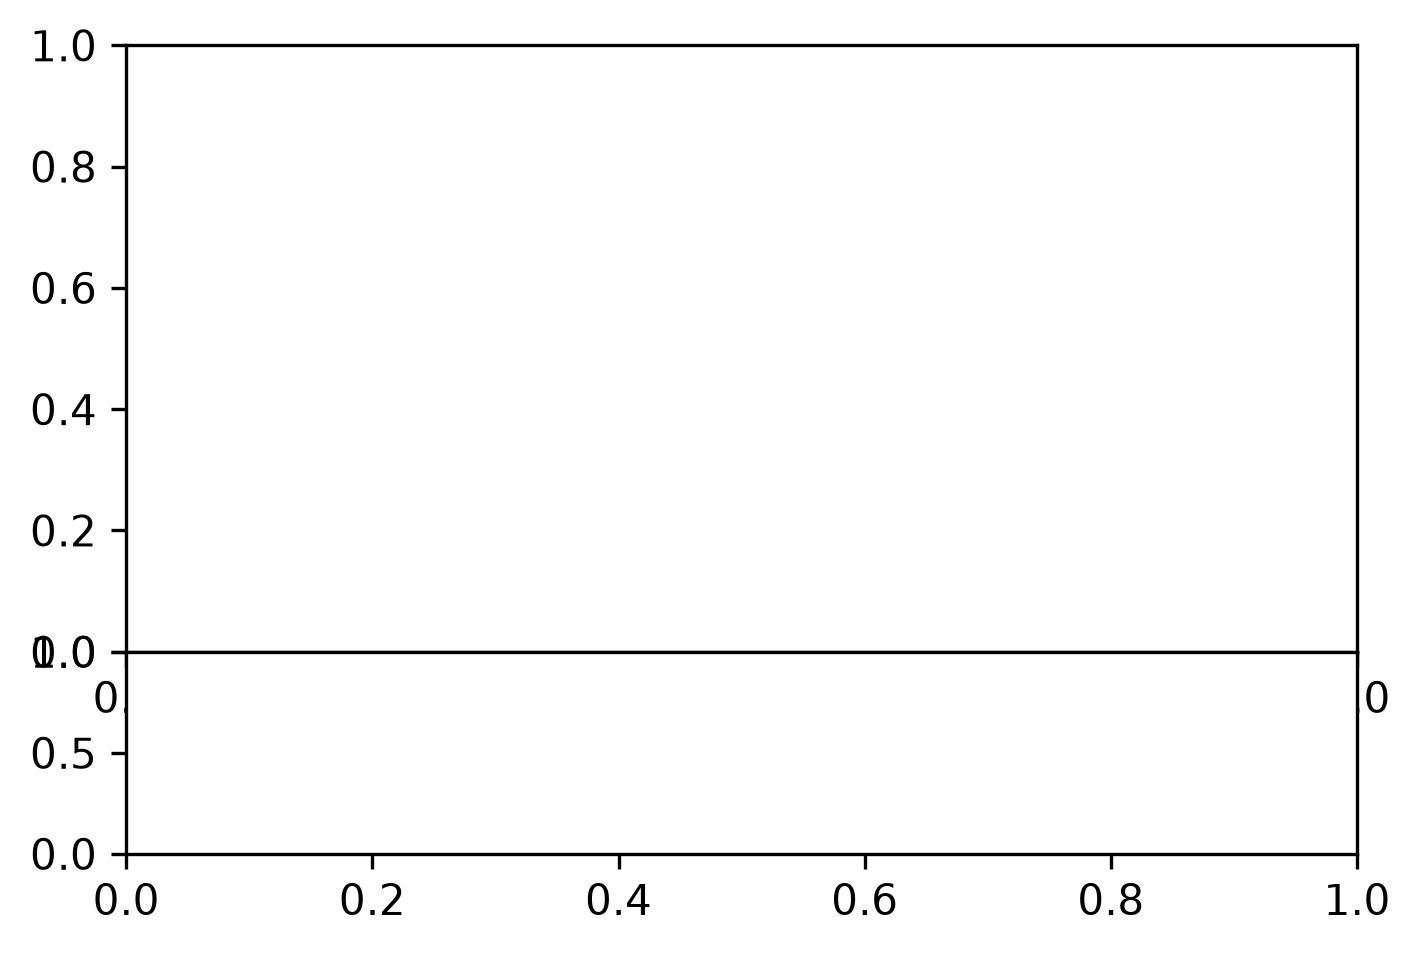

In [54]:
fig, axes = plot_detector_histograms(
    histograms,
    xlim=(0, 150),
    ratio_ylim=(0, 3),
)

# metadata

In [ ]:
detector = "V14673A"
version = "v1.2.1"
measure = "am_HS1_top_dlt"
run = 3
campaign = "c1"

In [ ]:
run_key = f"run{int(run):04d}"   # run0002: metadati
run_tag = f"r{int(run):03d}"     # r002: file LH5

In [ ]:
metadata_path = "/global/u2/r/ritaferi/HADES_DATA/hades-metadata"
db = dbetto.TextDB(metadata_path)


In [ ]:
db.hardware.configuration[detector]["c1"][measure]

In [ ]:
db_data = db.hardware.configuration[detector]["c1"][measure]['run0001']

In [ ]:
db_data

In [ ]:
db_bkg = db.hardware.configuration[detector]["c1"]["bkg"][f'run0001']

In [ ]:
db.hardware.configuration[detector]["c1"]["bkg"]

In [ ]:
db.hardware.configuration[detector]["c1"][measure]['run0003']

In [ ]:
# matches = find_matching_background_runs(
#     db,
#     detector=detector,
#     measure="am_HS1_top_dlt",
# )

# for run, info in matches.items():
#     backgrounds = ", ".join(info["background_runs"]) or "nessuno"

#     print(
#         f"{run} | card: {info['card_interface']} "
#         f"| background compatibili: {backgrounds}"
#     )



# Data

In [ ]:
file_pattern = (
    f"/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/"
    f"{version}/generated/tier/hit/{detector}/{campaign}/{measure}/"
    f"char_data-{detector}-{measure}-{run_tag}-*.lh5"
)

In [ ]:
file_pattern

In [ ]:
file_names = sorted(glob.glob(file_pattern))

In [ ]:
if not file_names:
    raise FileNotFoundError(
        f"Nessun file trovato per {detector}, {measure}, {run_key}:\n"
        f"{file_pattern}"
    )

print(f"{run_key}: {len(file_names)} file trovati")

In [ ]:
#data = lh5.read("hit", file_names)
#df = data.view_as("pd")

In [ ]:
emin = 0
emax = 7000
nbins = 7000
bins = np.linspace(emin, emax, nbins + 1)


In [ ]:
from pathlib import Path

force_rebuild = True  # True per forzare il ricalcolo

spectrum_dir = Path("raw_energy_spectrum")
spectrum_dir.mkdir(parents=True, exist_ok=True)

spectrum_path = spectrum_dir / (
    f"{detector}_{measure}_{run_key}_spectrum.npz"
)


In [ ]:

if spectrum_path.exists() and not force_rebuild:
    print(f"Carico: {spectrum_path}")

    with np.load(spectrum_path) as spectrum:
        counts_data = spectrum["counts"]
        bins = spectrum["bins"]

else:
    print(f"Creo: {spectrum_path}")
    # in questo modo salvo soltanto le informazioni che mi servono
    energy = lh5.read(
        "hit/cuspEmax_ctc_cal",
        file_names,
    ).nda

    counts_data, _ = np.histogram(energy, bins=bins)
    plt.stairs(counts_data, bins)
    plt.yscale('log')
    print(bins[1]-bins[0])

    np.savez_compressed(
        spectrum_path,
        counts=counts_data,
        bins=bins,
    )

    del energy

In [ ]:
print(f"Dimensione file: {spectrum_path.stat().st_size / 1024:.1f} KiB")

# Plot

In [55]:
import dbetto
import numpy as np
import matplotlib.pyplot as plt


def plot_source_positions_cylindrical(
    db,
    detector,
    measure="am_HS1_top_dlt",
    campaign="c1",
):
    configuration = (
        db.hardware.configuration[detector][campaign][measure]
    )

    # Raggruppa i run con la stessa posizione.
    positions = {}

    for run in sorted(configuration):
        if not (run.startswith("run") and run[3:].isdigit()):
            continue

        meta = (
            db.hardware.configuration[detector]
            [campaign][measure][run]
        )

        source = meta["source_position"]

        r = float(source["r_in_mm"])
        phi = float(source["phi_in_deg"]) % 360
        z = float(source["z_in_mm"])

        positions.setdefault((r, phi, z), []).append(run)

    if not positions:
        raise ValueError("Nessuna posizione della sorgente trovata.")

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")

    radii = sorted({position[0] for position in positions})
    colors = plt.get_cmap("viridis")(
        np.linspace(0.1, 0.9, len(radii))
    )

    for radius, color in zip(radii, colors):
        coordinates = []
        labels = []

        for (r, phi, z), runs in positions.items():
            if r != radius:
                continue

            coordinates.append((r, phi, z))

            run_numbers = ", ".join(
                str(int(run[3:])) for run in runs
            )
            labels.append(f"Run {run_numbers}")

        coordinates = np.asarray(coordinates)

        ax.scatter(
            coordinates[:, 0],
            coordinates[:, 1],
            coordinates[:, 2],
            s=65,
            color=color,
            edgecolors="black",
            linewidths=0.5,
            depthshade=False,
            label=f"r = {radius:g} mm",
        )

        for (r, phi, z), label in zip(coordinates, labels):
            ax.text(
                r + 1,
                phi + 3,
                z,
                label,
                fontsize=8,
                color=color,
            )

    r_min = min(radii)
    r_max = max(radii)
    r_margin = max(5.0, 0.15 * (r_max - r_min))

    z_values = [position[2] for position in positions]
    z_min = min(z_values)
    z_max = max(z_values)
    z_margin = max(1.0, 0.2 * (z_max - z_min))

    ax.set_xlim(max(0, r_min - r_margin), r_max + r_margin)
    ax.set_ylim(0, 360)
    ax.set_yticks(np.arange(0, 361, 45))
    ax.set_zlim(z_min - z_margin, z_max + z_margin)

    ax.set_xlabel("r (mm)")
    ax.set_ylabel("φ (°)")
    ax.set_zlabel("z (mm)")

    ax.set_box_aspect((1, 1, 0.4))
    ax.view_init(elev=25, azim=-55)

    ax.set_title(
        f"{detector} — {measure}\n"
        "Posizioni della sorgente in coordinate cilindriche"
    )

    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
    )

    fig.tight_layout()
    plt.show()

    return fig, ax

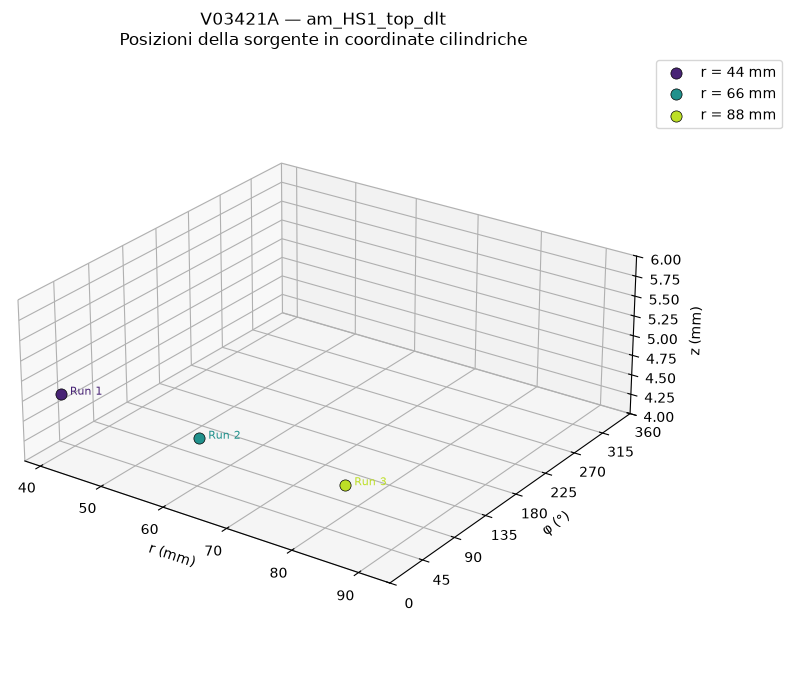

In [56]:
fig, ax = plot_source_positions_cylindrical(
    db,
    detector="V03421A",
    measure="am_HS1_top_dlt",
    campaign="c1",
)

In [57]:
# ============================================================
# ANNOTAZIONE
# ============================================================
detector = "V03421A"
source = db_data["source_position"]
card = db_data["daq_settings"]["flashcam"]["card_interface"]

annotation_measure = (
    f"Detector: {db_data['detector']}\n"
    f"Measure: {db_data['measurement']}\n"
    f"Run: {db_data['run']} "
    f"(T = {db_data['run_live_time_in_s'] / 3600:g} h)\n"
    f"Card interface: {card}\n"
    f"Voltage: {db_data['high_voltage_in_V']} V\n"
    f"z = {source['z_in_mm']:g} mm\n"
    f"r = {source['r_in_mm']:g} mm\n"
    f"φ = {source['phi_in_deg']:g}°"
)
annotation_measure

'Detector: V14673A\nMeasure: am_HS1_top_dlt\nRun: run0001 (T = 6 h)\nCard interface: efb3\nVoltage: 4900 V\nz = 5 mm\nr = 42 mm\nφ = 0°'

In [58]:
# Mantengo le energie che hai indicato
peaks = {
    "gamma_59p9keV": 59.9,
    "gamma_99keV": 99.0,
    "gamma_103keV": 103.0,
    "gamma_123p1keV": 123.1,
    "gamma_125p3keV": 125.3,
    "gamma_208p1keV": 208.1,
    "gamma_335p4keV": 335.4,
    "gamma_662p4keV": 662.4,
    "gamma":2615}

/tmp/ipykernel_2305045/3600781370.py:38: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 1e7)


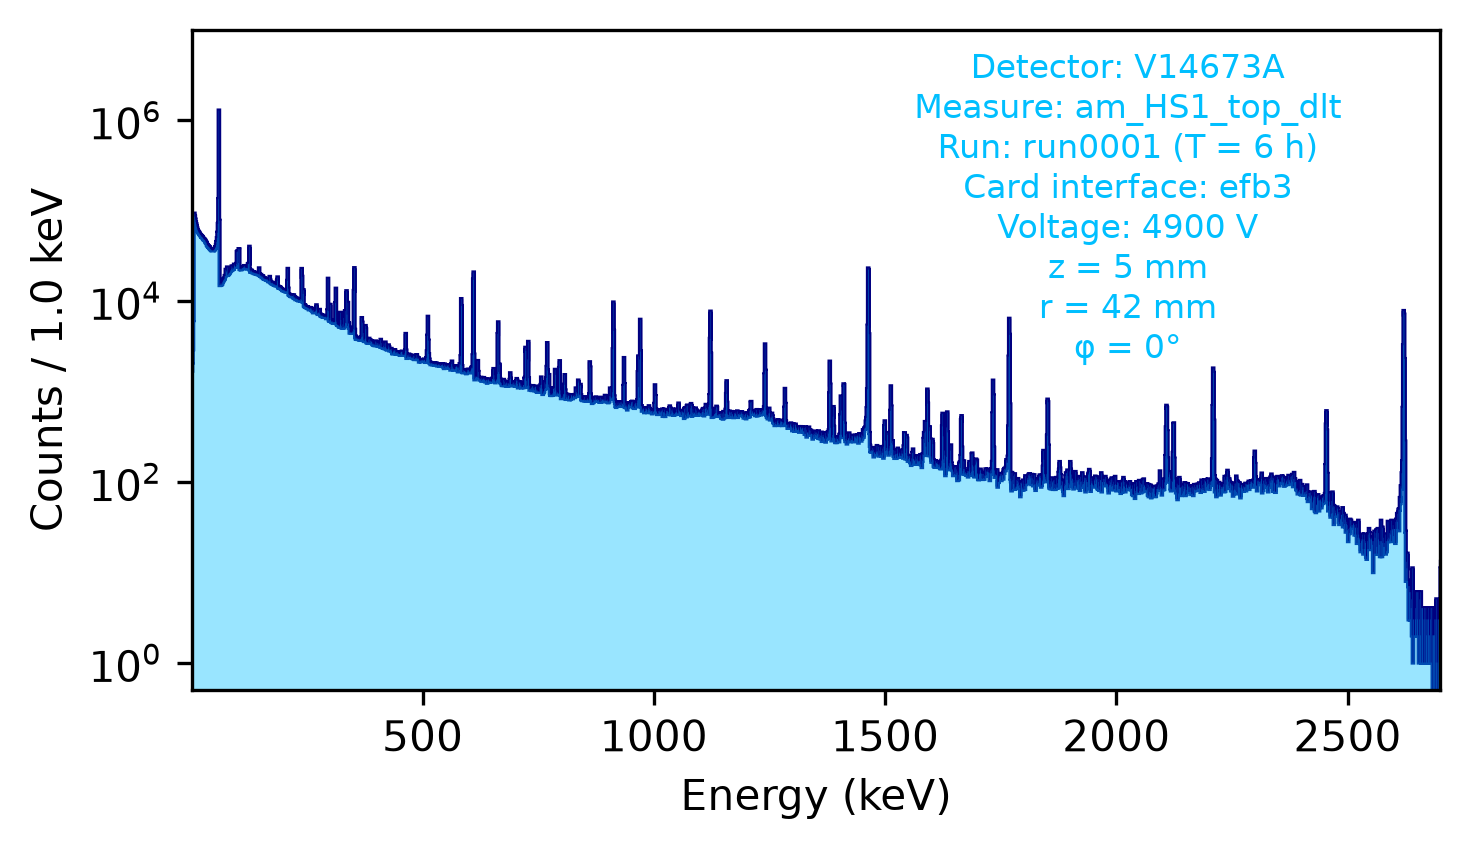

In [71]:
# ============================================================
# PLOT
# ============================================================
plt.figure(figsize=(5, 3), dpi = 300)

plt.stairs(
    counts_data,
    bins,
    color="navy",
)
plt.stairs(
    counts_data,
    bins,
    fill = True,
    alpha = 0.4,
    color="deepskyblue",
)

plt.annotate(
    annotation_measure,
    xy=(0.75, 0.97),
    xycoords="axes fraction",
    ha="center",
    va="top",
    multialignment="center",
    fontsize=8,
    zorder=8,
    color="deepskyblue",
)

# axvline non modifica i limiti verticali del grafico
#for energy in peaks.values():
#    plt.axvline(energy, color="red", linewidth=0.8)

#plt.axvline(2615, color="red", linewidth=0.8)

plt.yscale("log")
plt.ylim(0, 1e7)
plt.ylabel(f"Counts / {bins[1] - bins[0]:.1f} keV")
plt.xlabel("Energy (keV)")
plt.xlim(1, 2700)
plt.tight_layout()
plt.show()

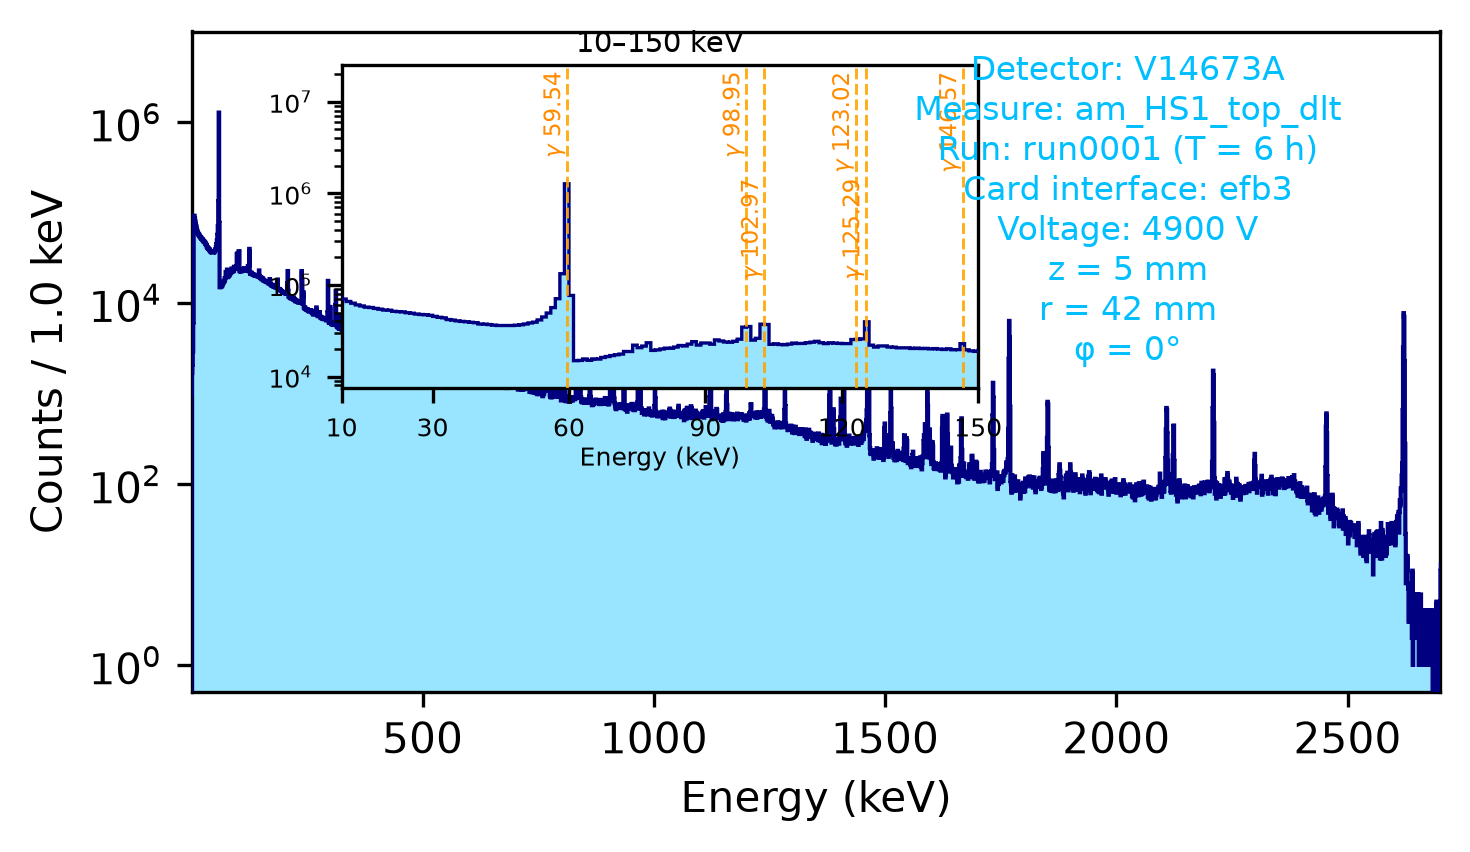

In [73]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# EXPECTED LOW-ENERGY LINES
# Energy in keV, label, vertical label position
# X-ray labels identify groups, not individual resolved lines.
# ============================================================

low_energy_lines = [
    (59.5409, r"$\gamma$ 59.54", 0.98),
    (98.95, r"$\gamma$ 98.95", 0.98),
    (102.97, r"$\gamma$ 102.97", 0.65),
    (123.02, r"$\gamma$ 123.02", 0.98),
    (125.29, r"$\gamma$ 125.29", 0.65),
    (146.57, r"$\gamma$ 146.57", 0.98),
]

# ============================================================
# MAIN PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(5, 3), dpi=300)

ax.stairs(
    counts_data,
    bins,
    color="navy",
    linewidth=1,
    zorder=3,
)

ax.stairs(
    counts_data,
    bins,
    fill=True,
    alpha=0.4,
    color="deepskyblue",
    zorder=2,
)

ax.annotate(
    annotation_measure,
    xy=(0.75, 0.97),
    xycoords="axes fraction",
    ha="center",
    va="top",
    multialignment="center",
    fontsize=8,
    zorder=8,
    color="deepskyblue",
)

ax.set_yscale("log")
ax.set_ylim(0.5, 1e7)
ax.set_xlim(1, 2700)

ax.set_ylabel(f"Counts / {bins[1] - bins[0]:.1f} keV")
ax.set_xlabel("Energy (keV)")

# ============================================================
# INSET: 10–150 keV
# [left, bottom, width, height] in main-axis coordinates
# ============================================================

axins = ax.inset_axes([0.12, 0.46, 0.51, 0.49])

axins.set_facecolor("white")

axins.stairs(
    counts_data,
    bins,
    color="navy",
    linewidth=0.8,
    zorder=3,
)

axins.stairs(
    counts_data,
    bins,
    fill=True,
    alpha=0.4,
    color="deepskyblue",
    zorder=2,
)

axins.set_yscale("log")
axins.set_xlim(10, 150)

centers = (bins[:-1] + bins[1:]) / 2

window = (centers >= 10) & (centers <= 150)
positive_counts = np.asarray(counts_data)[
    window & (np.asarray(counts_data) > 0)
]

if positive_counts.size:
    axins.set_ylim(
        max(0.5, positive_counts.min() / 2),
        positive_counts.max() * 20,
    )
else:
    axins.set_ylim(0.5, 10)

# ============================================================
# EXPECTED LINES AND LABELS
# x: data coordinates; y: fraction of inset height
# ============================================================

for energy, label, label_height in low_energy_lines:
    axins.axvline(
        energy,
        color="orange",
        linestyle="--",
        linewidth=0.7,
        alpha=0.9,
        zorder=4,
    )

    axins.text(
        energy,
        label_height,
        label,
        transform=axins.get_xaxis_transform(),
        rotation=90,
        ha="right",
        va="top",
        fontsize=5.5,
        color="darkorange",
        zorder=5,
    )

axins.set_xticks([10, 30, 60, 90, 120, 150])
axins.tick_params(axis="both", labelsize=6)

axins.set_title("10–150 keV", fontsize=7, pad=3)
axins.set_xlabel("Energy (keV)", fontsize=6, labelpad=1)

plt.tight_layout()
plt.show()

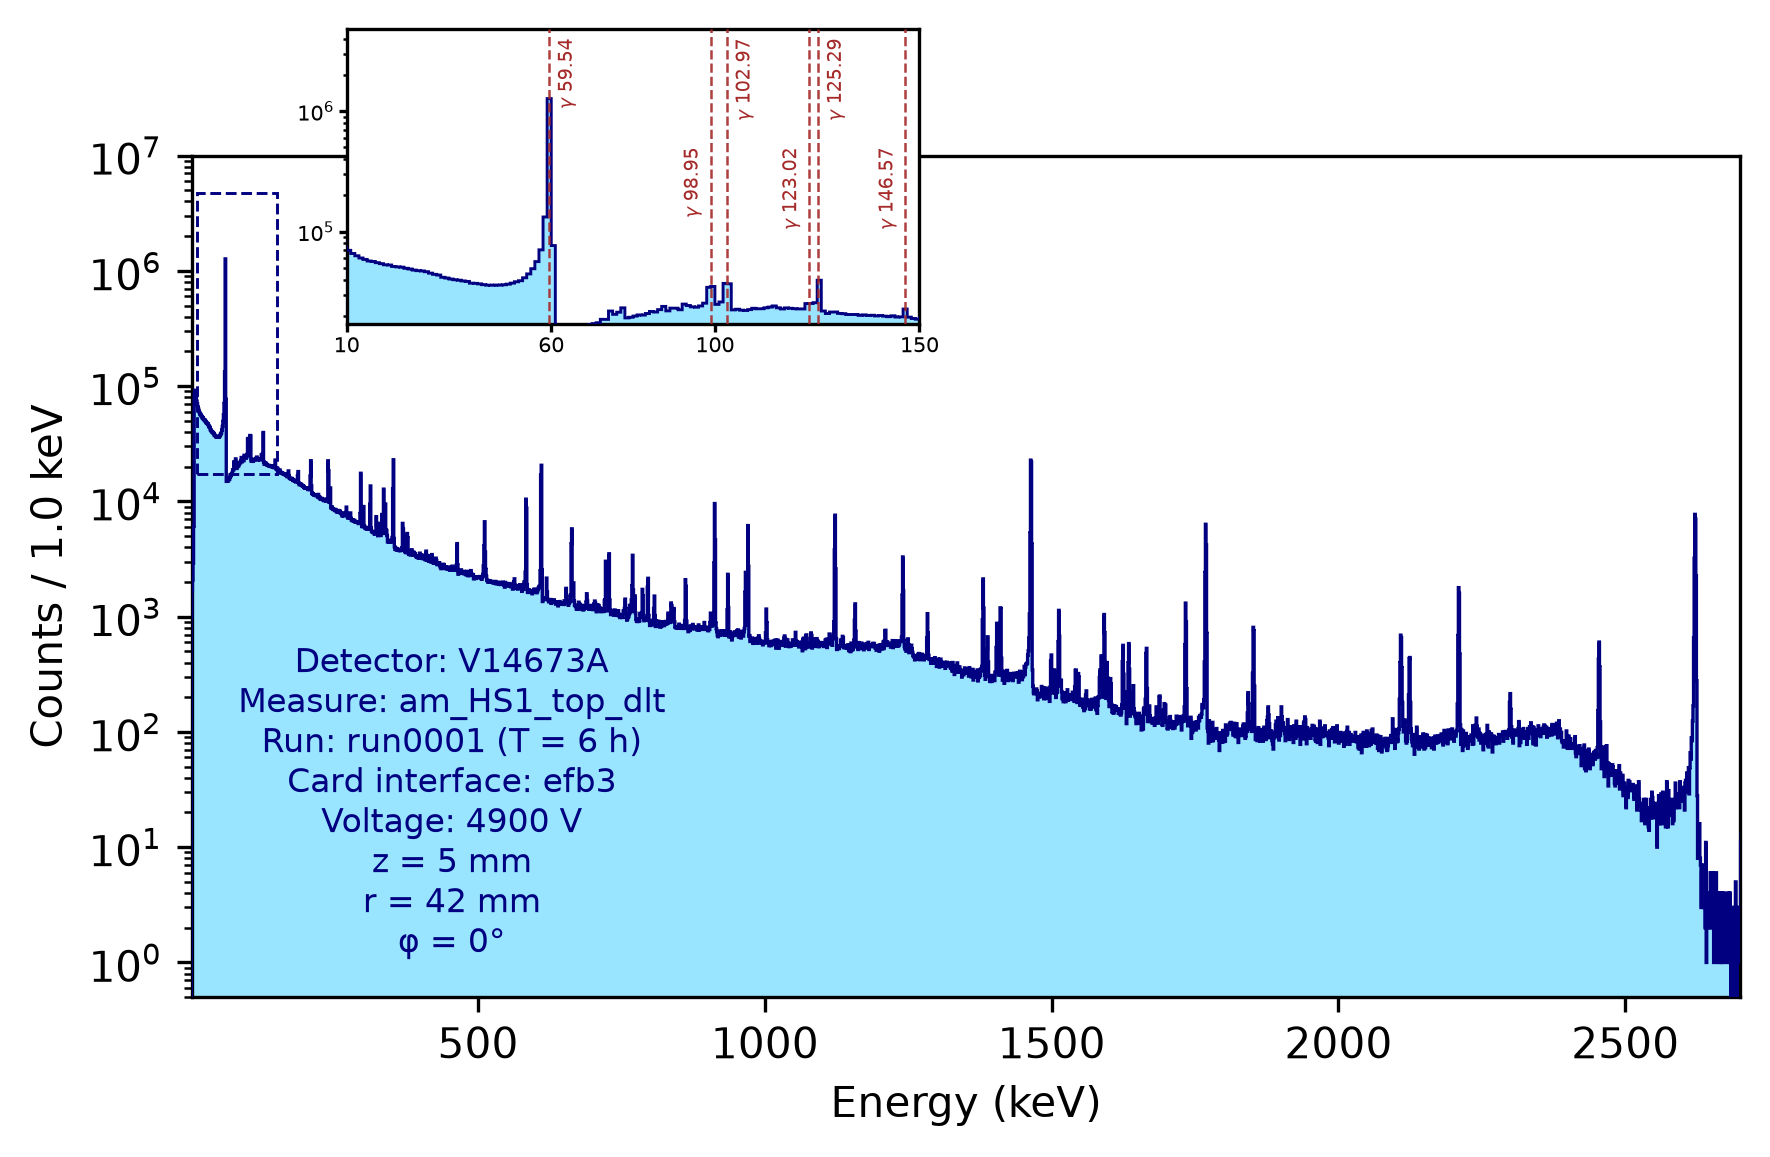

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

low_energy_lines = [
    (59.5409, r"$\gamma$ 59.54"),
    (98.95, r"$\gamma$ 98.95"),
    (102.97, r"$\gamma$ 102.97"),
    (123.02, r"$\gamma$ 123.02"),
    (125.29, r"$\gamma$ 125.29"),
    (146.57, r"$\gamma$ 146.57"),
]

counts = np.asarray(counts_data, dtype=float)
edges = np.asarray(bins, dtype=float)
centers = (edges[:-1] + edges[1:]) / 2

# ============================================================
# MAIN PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

ax.stairs(
    counts, edges,
    color="navy",
    linewidth=0.8,
    zorder=3,
)

ax.stairs(
    counts, edges,
    fill=True,
    alpha=0.4,
    color="deepskyblue",
    zorder=2,
)

ax.annotate(
    annotation_measure,
    xy=(0.03, 0.04),
    xycoords="axes fraction",
    ha="left",
    va="bottom",
    multialignment="center",
    fontsize=8,
    color="navy",
    zorder=7.5,
    
)

ax.set_yscale("log")
ax.set_ylim(0.5, 1e7)
ax.set_xlim(1, 2700)

ax.set_ylabel(f"Counts / {edges[1] - edges[0]:.1f} keV")
ax.set_xlabel("Energy (keV)")

# ============================================================
# SMALL INSET: UPPER RIGHT
# ============================================================

axins = ax.inset_axes([0.1, 0.8, 0.37, 0.35])
axins.set_facecolor("white")
axins.set_zorder(10)

axins.stairs(
    counts, edges,
    color="navy",
    linewidth=0.7,
    zorder=3,
)

axins.stairs(
    counts, edges,
    fill=True,
    alpha=0.4,
    color="deepskyblue",
    zorder=2,
)

window = (centers >= 10) & (centers < 150)
positive = counts[window & np.isfinite(counts) & (counts > 0)]

if positive.size:
    zoom_ymin = max(0.5, positive.min() / 1.3)*1.5
    zoom_ymax = min(8e6, positive.max() * 2.5)*1.5
else:
    zoom_ymin, zoom_ymax = 0.5, 10

axins.set_yscale("log")
axins.set_xlim(10, 150)
axins.set_ylim(zoom_ymin, zoom_ymax)

# ============================================================
# LINES AND ALTERNATING LABELS
# ============================================================

for index, (energy, label) in enumerate(low_energy_lines):
    axins.axvline(
        energy,
        color="brown",
        linestyle="--",
        linewidth=0.6,
        alpha=0.9,
        zorder=4,
    )

    right_side = index % 2 == 0

    axins.annotate(
        label,
        xy=(energy, 0.97 if right_side else 0.60),
        xycoords=axins.get_xaxis_transform(),
        xytext=(2 if right_side else -2, 0),
        textcoords="offset points",
        rotation=90,
        ha="left" if right_side else "right",
        va="top",
        fontsize=4.5,
        color="brown",
        zorder=5,
    )

axins.set_xticks([10, 60, 100, 150])
axins.tick_params(
    axis="both",
    which="major",
    labelsize=5,
    length=2,
    pad=1,
)
axins.tick_params(which="minor", length=1)

# ============================================================
# ZOOM RECTANGLE: NO LONG CONNECTORS
# Same energy and count limits as the inset.
# ============================================================

zoom_rectangle = Rectangle(
    (10, zoom_ymin),
    150 - 10,
    zoom_ymax - zoom_ymin,
    fill=False,
    edgecolor="navy",
    linewidth=0.7,
    linestyle="--",
    zorder=5,
)

ax.add_patch(zoom_rectangle)

plt.tight_layout()
plt.show()

In [426]:
time_measurement = db.hardware.configuration[detector]["c1"][measure][f'run0003']['run_live_time_in_s']
time_bkg = (db.hardware.configuration[detector]["c1"]["bkg"][f'run0002']["run_live_time_in_s"])

print(f'Time measurement : {time_measurement} s')
print(f'Time Background : {time_bkg} s')

Time measurement : 18000 s
Time Background : 61200 s


In [427]:
alpha = time_measurement  / time_bkg
print("\nNormalizzazione")
print(f"Tempo misura: {time_measurement:.2f} s")
print(f"Tempo background: {time_bkg:.2f} s")
print(f"Alpha: {alpha:.6f}")


Normalizzazione
Tempo misura: 18000.00 s
Tempo background: 61200.00 s
Alpha: 0.294118


In [432]:
# Stessi bin per tutti
emin = 0
emax = 7000
nbins = 7000

# Bordi comuni
bins = np.linspace(
    emin,
    emax,
    nbins + 1
)

In [433]:
# spettro dato misurati
counts_data, _ = np.histogram(
    df["cuspEmax_ctc_cal"],
    bins=bins,
    range = (emin, emax)
)

In [434]:
counts_bkg_raw, _ = np.histogram(
    df_bkg["cuspEmax_ctc_cal"],
    bins=bins,
    range = (emin, emax)
)

counts_bkg = counts_bkg_raw * alpha

In [435]:
# plot 3 run vs distanza
# plot a sofia
# cambia detector
# plot raw 

(1350.0, 1600.0)

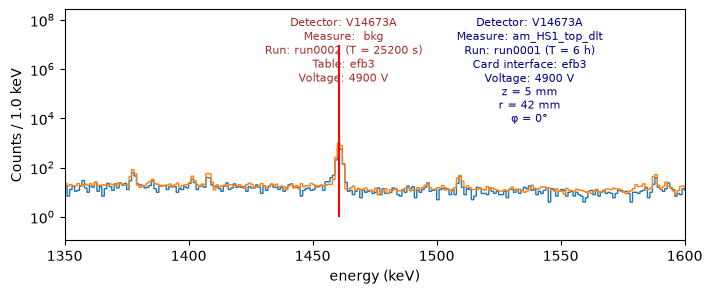

In [436]:
plt.figure(figsize=(8,3))
peaks = {
    "gamma_59p9keV": 59.9,
    "gamma_99keV": 99.0,
    "gamma_103keV": 103.0,
    "gamma_123p1keV": 123.1,
    "gamma_125p3keV": 125.3,
    "gamma_208p1keV": 208.1,
    "gamma_335p4keV": 335.4,
    "gamma_662p4keV": 662.4,
}
plt.annotate(
    annotation_measure,
    xy=(0.75, 0.97),
    xycoords="axes fraction",
    ha="center",
    va="top",
    multialignment="center",
    fontsize=8,
    zorder=8,
    color = 'navy'
)

plt.annotate(
    annotation_bkg,
    xy=(0.45, 0.97),
    xycoords="axes fraction",
    ha="center",
    va="top",
    multialignment="center",
    fontsize=8,
    zorder=8,
    color = 'brown'
)
plt.stairs(counts_data, bins, label = 'data uncolimated')
#plt.stairs(counts_colli, bins, label = 'data colimated')
plt.stairs(counts_bkg, bins, label = 'bkg (normalized)')
plt.yscale('log')
plt.ylabel(f'Counts / {bins[1]-bins[0]:.1f} keV')
plt.xlabel("energy (keV)")
plt.vlines(1460.82, 1, 1e7, color = 'red')
for n, p in peaks.items():
   plt.vlines(p, 1, 1e8, color = 'red')
plt.xlim(1350, 1600)

In [437]:
peaks = {
    "gamma_59p9keV": 59.9,
    "gamma_99keV": 99.0,
    "gamma_103keV": 103.0,
    "gamma_123p1keV": 123.1,
    #"gamma_125p3keV": 125.3,
    #"gamma_208p1keV": 208.1,
    #"gamma_335p4keV": 335.4,
    #"gamma_662p4keV": 662.4,
}


for n, e  in peaks.items():
    print(e)

59.9
99.0
103.0
123.1


Reading data and background...
Reading data and background...
Reading data and background...


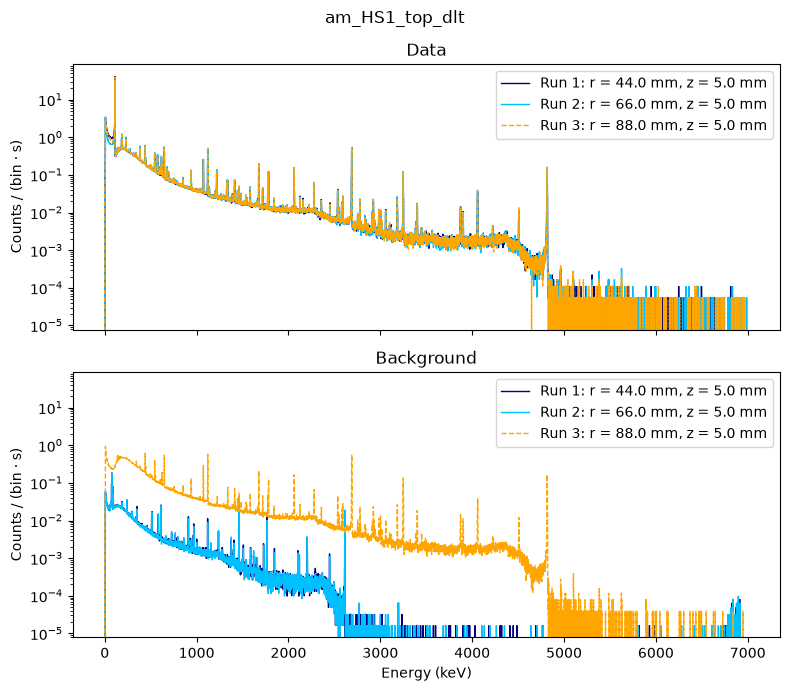

In [ ]:
import matplotlib.pyplot as plt
from itertools import cycle

measure = "am_HS1_top_dlt"
runs = ["1", "2", "3"]

data = {}
bkg = {}

for run in runs:
    data[run], bkg[run] = open_data(db, run, measure)


# ============================================================
# DATA E BACKGROUND: CONFRONTO TRA RUN
# ============================================================

fig, axes = plt.subplots(
    2, 1, figsize=(8, 7), sharex=True, sharey=True
)

colors = cycle(["navy", "deepskyblue", "orange"])
styles = cycle(["-", "-", "--"])

for run, color, ls in zip(runs, colors, styles):
    d = data[run]
    b = bkg[run]
    source = d["source_position"]

    label = (
        f"Run {run}: r = {source['r_in_mm']} mm, "
        f"z = {source['z_in_mm']} mm"
    )

    axes[0].stairs(
        d["counts_raw"] / d["time_s"],
        d["bins"],
        color=color,
        linestyle=ls,
        label=label,
    )

    axes[1].stairs(
        b["counts_raw"] / b["time_s"],
        b["bins"],
        color=color,
        linestyle=ls,
        label=label,
    )

axes[0].set_title("Data")
axes[1].set_title("Background")

for ax in axes:
    ax.set_yscale("log")
    ax.set_ylabel("Counts / (bin · s)")
    ax.legend()

axes[-1].set_xlabel("Energy (keV)")
fig.suptitle(measure)
fig.tight_layout()
plt.show()


# ============================================================
# DATA E BACKGROUND: UN PANNELLO PER RUN
# ============================================================

fig, axes = plt.subplots(
    len(runs),
    1,
    figsize=(8, 3 * len(runs)),
    sharex=True,
    sharey=True,
    squeeze=False,
)

axes = axes[:, 0]

for ax, run in zip(axes, runs):
    d = data[run]
    b = bkg[run]
    edges = d["bins"]
    source = d["source_position"]

    ax.stairs(
        d["counts_raw"] / d["time_s"],
        edges,
        color="deepskyblue",
        fill=True,
        label="Data",
    )

    ax.stairs(
        b["counts_raw"] / b["time_s"],
        b["bins"],
        color="navy",
        linestyle="--",
        label="Background",
    )

    ax.set_title(
        f"Run {run}: r = {source['r_in_mm']} mm, "
        f"z = {source['z_in_mm']} mm"
    )
    ax.set_yscale("log")
    ax.set_ylabel(
        f"Counts / ({edges[1] - edges[0]:.0f} keV · s)"
    )
    ax.legend()

axes[-1].set_xlabel("Energy (keV)")
fig.suptitle(measure)
fig.tight_layout()
plt.show()

In [ ]:
measure = "am_HS6_top_dlt"
runs = ["1", "2"]#, "3"]
from itertools import cycle

data = {}
bkg = {}

for run in runs:
    data[run], bkg[run] = open_data(db, run, measure)


# ============================================================
# DATA E BACKGROUND: CONFRONTO TRA RUN
# ============================================================

fig, axes = plt.subplots(
    2, 1, figsize=(8, 7), sharex=True, sharey=True
)

colors = cycle(["navy", "deepskyblue", "orange"])
styles = cycle(["-", "-", "--"])

for run, color, ls in zip(runs, colors, styles):
    d = data[run]
    b = bkg[run]
    source = d["source_position"]

    label = (
        f"Run {run}: r = {source['r_in_mm']} mm, "
        f"z = {source['z_in_mm']} mm"
    )

    axes[0].stairs(
        d["counts_raw"] / d["time_s"],
        d["bins"],
        color=color,
        linestyle=ls,
        label=label,
    )

    axes[1].stairs(
        b["counts_raw"] / b["time_s"],
        b["bins"],
        color=color,
        linestyle=ls,
        label=label,
    )

axes[0].set_title("Data")
axes[1].set_title("Background")

for ax in axes:
    ax.set_yscale("log")
    ax.set_ylabel("Counts / (bin · s)")
    ax.legend()

axes[-1].set_xlabel("Energy (keV)")
fig.suptitle(measure)
fig.tight_layout()
plt.show()


In [ ]:


# ============================================================
# DATA E BACKGROUND: UN PANNELLO PER RUN
# ============================================================

fig, axes = plt.subplots(
    len(runs[:1]),
    1,
    figsize=(6, 2.5 * len(runs)),
    sharex=True,
    sharey=True,
    squeeze=False,
    dpi = 300
)

axes = axes[:, 0]

for ax, run in zip(axes, runs):
    d = data[run]
    b = bkg[run]
    edges = d["bins"]
    source = d["source_position"]

    ax.stairs(
        d["counts_raw"] / d["time_s"],
        edges,
        color="deepskyblue",
        fill=True,
        label="Data",
    )

    ax.stairs(
        b["counts_raw"] / b["time_s"],
        b["bins"],
        color="navy",
        #linestyle="--",
        label="Background",
    )

    ax.set_title(
        f"Run {run}: r = {source['r_in_mm']} mm, "
        f"z = {source['z_in_mm']} mm"
    )
    ax.set_yscale("log")
    ax.set_ylabel(
        f"Counts / ({edges[1] - edges[0]:.0f} keV · s)"
    )
    ax.legend()
axes[-1].set_xlim(0, 3000)
axes[-1].set_xlabel("Energy (keV)")
fig.suptitle(measure)
fig.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

measure = "am_HS6_top_dlt"
runs = ["1", "2"]#, "3"]

data = {}
bkg = {}

for run in runs:
    data[run], bkg[run] = open_data(db, run, measure)

# Usa il tuo dizionario peaks: {nome: energia in keV}

# ============================================================
# DATA E BACKGROUND: UN GRAFICO SEPARATO PER RUN
# ============================================================


In [ ]:
fig, axes = plt.subplots(
    2, 1, figsize=(8, 7), sharex=True, sharey=True
)

for run, ax in zip(runs, axes):
    d = data[run]
    edges = d["bins"]
    source = d["source_position"]

    ax.stairs(
        d["counts_raw"] / d["time_s"],
        edges,
        color="deepskyblue",
        fill=True,
        label="Data",
    )

    for name, energy in peaks.items():
        ax.axvline(
            energy,
            color="crimson",
            linestyle=":",
            linewidth=1,
            alpha=0.8,
        )

        ax.text(
            energy,
            0.95,
            f"{energy:g} keV",
            transform=ax.get_xaxis_transform(),
            rotation=90,
            va="top",
            ha="right",
            fontsize=9,
            color="crimson",
        )

    ax.set_title(
        f"Run {run}: r = {source['r_in_mm']} mm, "
        f"z = {source['z_in_mm']} mm"
    )
    ax.set_xlim(10, 150)
    ax.set_yscale("log")
    ax.set_ylabel(
        f"Counts / ({edges[1] - edges[0]:.0f} keV · s)"
    )
    ax.legend()

axes[-1].set_xlabel("Energy (keV)")
fig.suptitle(measure)
fig.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

measure = "am_HS1_top_dlt"
runs = ["1", "2", "3"]

data = {}
bkg = {}

for run in runs:
    data[run], bkg[run] = open_data(db, run, measure)

# Usa il tuo dizionario peaks: {nome: energia in keV}

# ============================================================
# DATA E BACKGROUND: UN GRAFICO SEPARATO PER RUN
# ============================================================


In [ ]:
fig, axes = plt.subplots(
    3, 1, figsize=(12, 7), sharex=True, sharey=True
)

for run, ax in zip(runs, axes):
    d = data[run]
    edges = d["bins"]
    source = d["source_position"]

    ax.stairs(
        d["counts_raw"] / d["time_s"],
        edges,
        color="deepskyblue",
        fill=True,
        label="Data",
    )

    for name, energy in peaks.items():
        ax.axvline(
            energy,
            color="crimson",
            linestyle=":",
            linewidth=1,
            alpha=0.8,
        )

        ax.text(
            energy,
            0.95,
            f"{energy:g} keV",
            transform=ax.get_xaxis_transform(),
            rotation=90,
            va="top",
            ha="right",
            fontsize=9,
            color="crimson",
        )

    ax.set_title(
        f"Run {run}: r = {source['r_in_mm']} mm, "
        f"z = {source['z_in_mm']} mm"
    )
    ax.set_xlim(10, 150)
    ax.set_yscale("log")
    ax.set_ylabel(
        f"Counts / ({edges[1] - edges[0]:.0f} keV · s)"
    )
    ax.legend()

axes[-1].set_xlabel("Energy (keV)")
fig.suptitle(measure)
fig.tight_layout()
plt.show()

# from pyg4ometry import gdml

if os.path.isfile(gdml_file):
    reg = gdml.Reader(gdml_file).getRegistry()
    print(f"GDML caricato: {gdml_file}")
else:
    raise FileNotFoundError(gdml_file)Simulation

In [34]:
run = "run0001"
config_geom = deepcopy(configuration[run])

gdml_file = os.path.join(
    output_dir, f"{detector}_{measure}_{run}.gdml"
)

if os.path.isfile(gdml_file):
    reg = gdml.Reader(gdml_file).getRegistry()
    print(f"GDML già presente, caricato: {gdml_file}")
else:
    reg = pygeomhades.core.construct(config_geom)
    os.makedirs(output_dir, exist_ok=True)
    write_pygeom(reg, gdml_file)
    print(f"GDML creato: {gdml_file}")

NameError: name 'configuration' is not defined

In [ ]:

placements = collect_global_placements(reg.getWorldVolume())

detector_name = find_germanium_detector(reg)

components = {
    "cavity_lv": {
        "label": "cavity",
        "color": "tab:blue"
    },
    "Wrap": {
        "label": "wrap",
        "color": "tab:orange"
    },
    "Holder": {
        "label": "holder",
        "color": "tab:green"
    },
    detector_name: {
        "label": "detector",
        "color": "tab:red"
    },
    "Cryostat": {
        "label": "cryo",
        "color": "tab:purple"
    },
}

fig, ax = plt.subplots(figsize=(4,8))

for logical_name, style in components.items():

    if logical_name not in placements:
        print(f"Volume non trovato: {logical_name}")
        continue

    # Se esistono più copie, le disegna tutte
    for index, placement in enumerate(placements[logical_name]):

        lv = placement["logical_volume"]
        matrix = placement["matrix"]

        try:
            r_local, z_local = get_profile(lv.solid)
        except TypeError as error:
            print(error)
            continue

        radius, height = transform_profile(
            r_local,
            z_local,
            matrix
        )

        # Una sola voce in legenda per componente
        label = style["label"] if index == 0 else None

        ax.plot(
            radius,
            height,
            color=style["color"],
            linewidth=1.3,
            label=label
        )

ax.set_title(detector_name, fontsize=16)
ax.set_xlabel("radius (mm)")
ax.set_ylabel("height (mm)")

ax.set_xlim(left=-2)
ax.set_aspect("equal", adjustable="box")

ax.grid(alpha=0.15)
ax.legend(loc = 'lower right')

plt.tight_layout()
plt.show()

In [ ]:
from remage import remage_run



In [ ]:
peaks = {
    "gamma_59p9keV": 59.9,
    "gamma_99keV": 99.0,
    "gamma_103keV": 103.0,
    "gamma_123p1keV": 123.1,
    "gamma_125p3keV": 125.3,
    "gamma_208p1keV": 208.1,
    "gamma_335p4keV": 335.4,
    "gamma_662p4keV": 662.4,
}

N_sim = 1_000
force_rerun = False

os.makedirs(output_dir, exist_ok=True)
simulation_files = {}

for name, energy_keV in peaks.items():

    output_file = os.path.join(
        output_dir,
        f"{detector}_{measure}_{run}_{name}.lh5"
    )

    if os.path.isfile(output_file) and not force_rerun:
        simulation_files[name] = output_file
        print(f"✅ {name}: uso il file esistente → {output_file}")
        continue

    macro = [
        "/RMG/Manager/Logging/LogLevel summary",
        "/RMG/Processes/HadronicPhysics Shielding",
        f"/RMG/Geometry/RegisterDetector Germanium {detector} 1",
        "/RMG/Output/NtupleUseVolumeName true",
        "/RMG/Output/NtuplePerDetector false",
        "/run/initialize",
        "/RMG/Generator/Confine Volume",
        "/RMG/Generator/Confinement/Physical/AddVolume Source_PV",
        "/RMG/Generator/Select GPS",
        "/gps/particle gamma",
        "/gps/ene/type Mono",
        f"/gps/energy {energy_keV} keV",
        "/gps/ang/type iso",
        f"/run/beamOn {N_sim}",
    ]

    print(f"▶ {name}: avvio simulazione → {output_file}")

    try:
        remage_run(
            macros=macro,
            gdml_files=gdml_file,
            output=output_file,
            overwrite_output=True,
        )
        simulation_files[name] = output_file
        print(f"✅ {name}: simulazione completata")

    except Exception as e:
        print(f"❌ {name}: {e}")

print("\nFile disponibili:", simulation_files)

In [ ]:
N_sim_by_peak = {}
energies = ["gamma_59p9keV", "gamma_99keV","gamma_103keV",
    "gamma_123p1keV",
    "gamma_125p3keV",
    "gamma_208p1keV",
    "gamma_335p4keV"]

for name in energies:
    filename = os.path.join(
        output_dir, f"{detector}_{measure}_{run}_{name}.lh5"
    )

    obj = lh5.read("number_of_simulated_events", filename)

    # Compatibilità con versioni che restituiscono una tupla
    if isinstance(obj, tuple):
        obj = obj[0]

    N_sim_by_peak[name] = int(obj.value)
    print(f"{name}: {N_sim_by_peak[name]:,} eventi simulati")

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
has_counts = False

for i, (name, energy_keV) in enumerate(peaks.items()):

    filename = simulation_files.get(
        name,
        os.path.join(
            output_dir,
            f"{detector}_{measure}_{run}_{name}.lh5"
        )
    )

    print("PATH:", filename, "| esiste:", os.path.isfile(filename))

    try:
        data = lh5.read_as("stp/germanium", filename, "ak")
        energy = ak.to_numpy(ak.sum(data.edep, axis=-1))
        energy = energy[energy > 0]

        counts, _ = np.histogram(energy, bins=bins)

        if counts.sum() == 0:
            print(f"{name}: nessun deposito nell'intervallo del grafico")
            continue

        ax.stairs(
            counts,
            bins,
            #color=colors[i % len(colors)],
            label=f"{energy_keV:g} keV"
        )
        has_counts = True

    except Exception:
        print(f"Errore durante la lettura o il grafico di {name}:")
        traceback.print_exc()

if has_counts:
    ax.set_xlabel("Energy deposited [keV]")
    ax.set_ylabel("Counts / 1 keV")
    ax.set_xlim(emin, emax)
    ax.set_yscale("log")
    ax.legend(title="Gamma generato")
    fig.tight_layout()
    plt.show()
else:
    plt.close(fig)
    print("Nessun conteggio da mostrare")

In [ ]:
BR = {
    "gamma_59p9keV":  0.359,
    "gamma_99keV":    2.03e-4,
    "gamma_103keV":   1.95e-4,
    "gamma_123p1keV": 1.00e-5,
    "gamma_125p3keV": 4.08e-5,
    "gamma_208p1keV": 7.91e-6,
    "gamma_335p4keV": 4.96e-6,
}


In [ ]:

activity = 4330e3  # Bq: valore nominale comune alla misura

counts_theory = np.zeros(len(bins) - 1)
counts_smeared = np.zeros(len(bins) - 1)

for name, br in BR.items():

    filename = os.path.join(
        output_dir, f"{detector}_{measure}_{run}_{name}.lh5"
    )

    # Gli errori di lettura vengono mostrati, evitando somme incomplete
    data = lh5.read_as("stp/germanium", filename, "ak")
    energy = ak.to_numpy(ak.sum(data.edep, axis=-1))
    energy = energy[energy > 0]

    if len(energy) == 0:
        print(f"{name}: nessun deposito positivo di energia")
        continue

    energy_smeared = ak.to_numpy(
        reboost.math.stats.gaussian_sample(energy, sigma=1)
    )

    N_sim = N_sim_by_peak[name]
    if N_sim <= 0:
        raise ValueError(f"{name}: N_sim deve essere positivo")

    # BR applicato una sola volta, nel peso
    peso = activity * time_measurement * br / N_sim
    weights = np.full(len(energy), peso)

    counts_iso, _ = np.histogram(
        energy, bins=bins, weights=weights
    )
    counts_iso_smeared, _ = np.histogram(
        energy_smeared, bins=bins, weights=weights
    )

    counts_theory += counts_iso
    counts_smeared += counts_iso_smeared

    print(f"{name}: N_sim = {N_sim:,}, peso = {peso:.6g}")

counts_MC = counts_smeared

In [ ]:
plt.figure(figsize=(5,3), dpi = 300)

plt.stairs(
    counts_theory,
    bins,
    fill = True,
    color="navy",
    label="theory"
)

plt.stairs(
    counts_smeared,
    bins,
    color="deepskyblue",
    label="smeared")

plt.xlabel("Energy [keV]")
plt.ylabel(f"Counts / {bins[1]-bins[0]:.0f} keV")
plt.ylim(0.5, 1e7)
plt.yscale("log")
plt.xlim(0, 500)
#plt.vlines(59.9, 1, 100000, color = 'orange')
#plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(5,3), dpi = 300)

plt.stairs(
    counts_smeared + counts_bkg,
    bins,
    #fill = True,
    color="navy",
    label="MC"
)

plt.stairs(
    counts_bkg,
    bins,
    #fill = True,
    color="orange",
    label="BKG"
)


plt.xlabel("Energy [keV]")
plt.ylabel(f"Counts / {bins[1]-bins[0]:.0f} keV")
plt.ylim(0.5, 1e6)
plt.yscale("log")
#plt.vlines(59.9, 1, 100000, color = 'orange')
#plt.grid(alpha=0.25)
plt.legend()
plt.xlim(emin, 700)
plt.tight_layout()
plt.show()

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(figsize=(5, 3), dpi=300)

ax.stairs(
    counts_smeared + counts_bkg,
    bins,
    #color="navy",
    label="MC + BKG"
)

ax.stairs(
    counts_bkg,
    bins,
    color="orange",
    label="BKG"
)

ax.set_xlabel("Energy [keV]")
ax.set_ylabel(f"Counts / {bins[1] - bins[0]:g} keV")
ax.set_ylim(0.5, 1e6)
ax.set_yscale("log")
ax.set_xlim(emin, 700)
ax.legend(loc="lower left")

# Inset: 0–150 keV
axins = inset_axes(
    ax,
    width="45%",
    height="48%",
    loc="upper right",
    borderpad=1
)

axins.stairs(
    counts_smeared + counts_bkg,
    bins,
    #color="navy"
)

axins.stairs(
    counts_bkg,
    bins,
    color="orange"
)

axins.set_xlim(0, 150)
axins.set_ylim(0.5, 1e7)
axins.set_yscale("log")
axins.tick_params(axis="both", labelsize=7)
#axins.set_title("0–150 keV", fontsize=8)

fig.subplots_adjust(left=0.15, bottom=0.18, right=0.97, top=0.96)
plt.show()

# data comparison

In [ ]:

plt.figure(figsize=(6,4), dpi = 300)

plt.stairs(
    counts_MC , 
    bins,
    fill = True,
    alpha = 0.6,
    label="MC normalized"
)

plt.stairs(
    counts_MC + counts_bkg, 
    bins,
    #fill = True,
    alpha = 0.6,
    label="MC + bkg"
)



plt.stairs(
    counts_data,
    bins,
    #fill = True,
    #color="deepskyblue",
    label="Data",
    zorder = 10
)

plt.stairs(
    counts_bkg,
    bins,
    label="Bkg",
    zorder = 10
)



plt.xlim(0, 700)
plt.yscale("log")
plt.xlabel("Energy (keV)")
plt.ylabel("Counts")
plt.legend()

#ùplt.vlines(2614, 1, 1e5, color = 'red')

plt.tight_layout()
plt.show()


